### Pacotes importados

In [9]:
import Pkg
Pkg.add("Plots")

using LinearAlgebra
using Plots


   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`


## Chapter 13: Quasi-Newton methods

### Algorithm 13.1: Quasi-Newton BFGS method

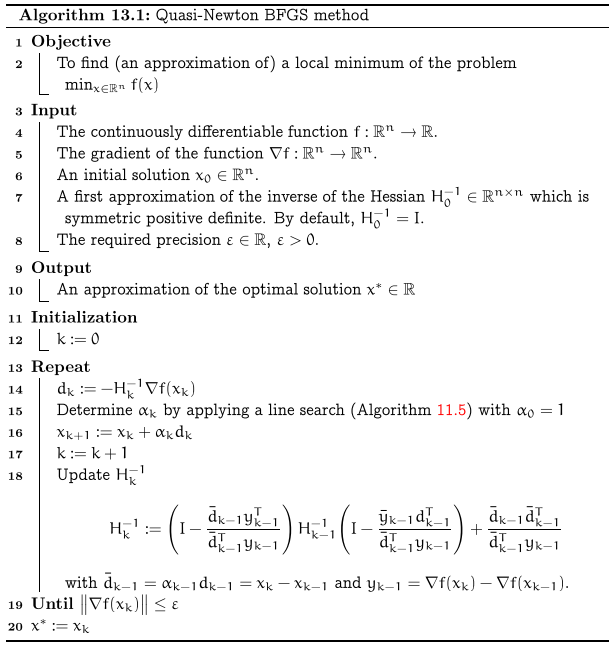

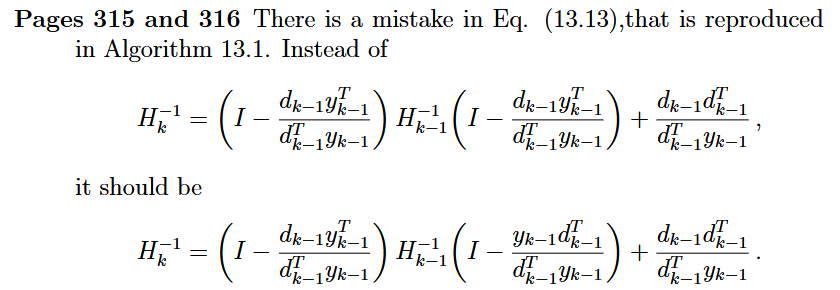

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$

In [25]:
function bfgs_plot(f, gradf, x0, epi; max_iter=1000)
    n = length(x0)

    x = copy(x0)
    H = Matrix{Float64}(I, n, n)   # H0^{-1}

    xs = [copy(x)]
    erros = [norm(gradf(x))]
    valores = [f(x)]

    k = 0

    while norm(gradf(x)) > epi && k < max_iter
        g = gradf(x)

        d = -H * g

        alpha, _ = line_search_wolfe(f, gradf, x, d, 1.0)

        x_new = x + alpha*d
        g_new = gradf(x_new)

        d_k = x_new - x
        y_k = g_new - g

        denom = dot(d_k, y_k)

        if denom <= 1e-12
            # evita instabilidade
            H = Matrix{Float64}(I, n, n)
        else
            I_n = Matrix{Float64}(I, n, n)

            H = (I_n - (d_k*y_k')/denom) * H *
                (I_n - (y_k*d_k')/denom) +
                (d_k*d_k')/denom
        end

        x = x_new

        push!(xs, copy(x))
        push!(erros, norm(gradf(x)))
        push!(valores, f(x))

        k += 1
    end

    return x, xs, erros, valores, k
end

function plot_bfgs(f, gradf, x0, epi; titulo="BFGS")
    x_aprox, xs, erros, valores, iter = bfgs_plot(f, gradf, x0, epi)

    k_vals = 0:length(xs)-1
    x1_vals = [x[1] for x in xs]
    x2_vals = [x[2] for x in xs]

    println("Solução: ", x_aprox)
    println("Iterações: ", iter)
    println("Gradiente final: ", erros[end])

    p1 = plot(k_vals, x1_vals, label="x1", marker=:circle)
    plot!(p1, k_vals, x2_vals, label="x2", marker=:diamond)

    p2 = plot(k_vals, erros, yscale=:log10, label="||grad||")

    p3 = plot(
    k_vals,
    valores,
    label="f(x)",
    size=(600,400)
)

    display(p1)
    display(p2)
    display(p3)

    return x_aprox
end

function line_search_wolfe(f, gradf, x, d, alpha0;
                           beta1=1e-4, beta2=0.99, lambda=2.0, max_iter=100)

    alpha_l = 0.0
    alpha_r = Inf
    alpha = alpha0

    fx = f(x)
    gx = gradf(x)
    gxd = dot(gx, d)

    i = 0

    while i < max_iter
        f_new = f(x + alpha*d)
        g_new = gradf(x + alpha*d)

        # Condicao 11.45: Armijo
        armijo = f_new <= fx + beta1*alpha*gxd

        # Condicao 11.47: curvatura de Wolfe
        curvatura = dot(g_new, d) >= beta2*gxd

        if armijo && curvatura
            return alpha, i
        end

        if !armijo
            # passo muito grande
            alpha_r = alpha
            alpha = (alpha_l + alpha_r)/2
        else
            # passo muito pequeno
            alpha_l = alpha

            if isfinite(alpha_r)
                alpha = (alpha_l + alpha_r)/2
            else
                alpha = lambda*alpha
            end
        end

        i += 1
    end

    return alpha, i
end

line_search_wolfe (generic function with 1 method)

Solução: [-1.0000000157069548, -1.6666152366576187e-8]
Iterações: 11
Gradiente final: 2.2901289865686694e-8


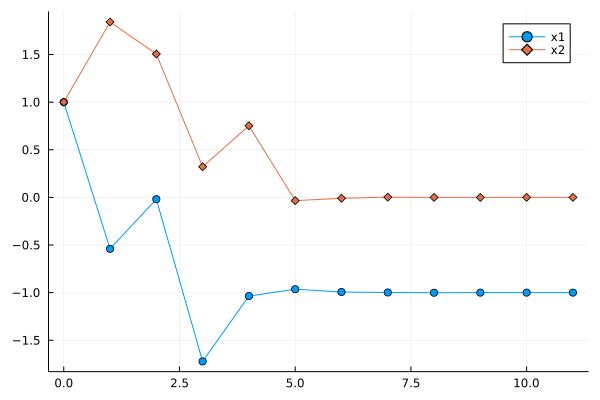

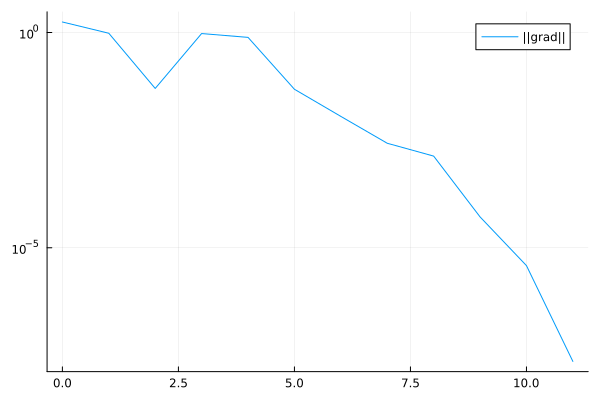

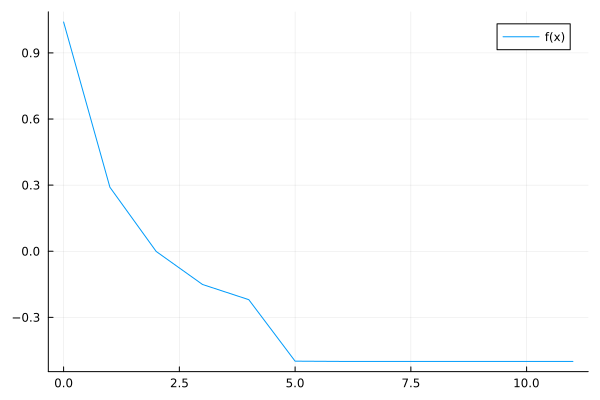

2-element Vector{Float64}:
 -1.0000000157069548
 -1.6666152366576187e-8

In [26]:
f(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

gradf(x) = [
    x[1] + cos(x[2]);
    -x[1]*sin(x[2])
]

x0 = [1.0, 1.0]
epi = 1e-6

plot_bfgs(f, gradf, x0, epi, titulo="BFGS - Exemplo 5.8")

#### the Rosenbrock problem

In [21]:

function steepest_descent_plot(f, gradf, x0, epi; max_iter=10000)
    x = copy(x0)

    xs = [copy(x)]
    erros = [norm(gradf(x))]
    valores = [f(x)]
    alphas = Float64[]

    k = 0

    while norm(gradf(x)) > epi && k < max_iter
        d = -gradf(x)

        alpha, _ = line_search_wolfe(f, gradf, x, d, 1.0)

        x = x + alpha*d

        push!(xs, copy(x))
        push!(erros, norm(gradf(x)))
        push!(valores, f(x))
        push!(alphas, alpha)

        k += 1
    end

    return x, xs, erros, valores, alphas, k
end

steepest_descent_plot (generic function with 1 method)

In [22]:
function rosenbrock(x)
    soma = 0.0
    for i in 1:length(x)-1
        soma += 100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2
    end
    return soma
end

function grad_rosenbrock(x)
    n = length(x)
    g = zeros(n)

    for i in 1:n-1
        g[i] += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end

    return g
end

x0 = [-1.2, 1.0]
epi = 1e-6

x_aprox, xs, erros, valores, alphas, iter = steepest_descent_plot(
    rosenbrock,
    grad_rosenbrock,
    x0,
    epi
)

println("Solução aproximada: ", x_aprox)
println("Iterações: ", iter)
println("Norma final: ", erros[end])
println("Valor final f(x): ", valores[end])

Solução aproximada: [0.9999885309112244, 0.9999770472967094]
Iterações: 10000
Norma final: 1.7325138726746607e-5
Valor final f(x): 1.31561480926143e-10


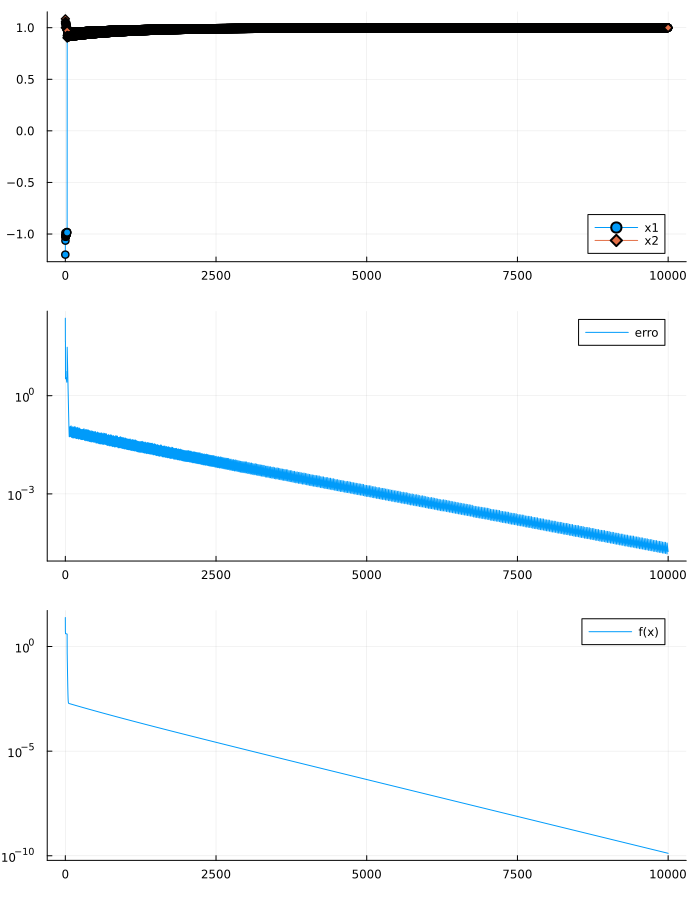

In [24]:
p1 = plot(k_vals, x1_vals, marker=:circle, label="x1")
plot!(p1, k_vals, x2_vals, marker=:diamond, label="x2")

p2 = plot(k_vals, erros, yscale=:log10, label="erro")

p3 = plot(k_vals, valores, yscale=:log10, label="f(x)")

plot(p1, p2, p3, layout=(3,1), size=(700,900))